<a href="https://colab.research.google.com/github/RAVIAPTISWETHA/COVID-19-Detection-from-Chest-X-ray-Images-Using-CNN-/blob/main/COVID_19_DETECTIOIN_FROM_CHEST_X_RAY_IMAGES_USING_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Installing Libraries



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
import os
from PIL import Image
import random
import hashlib
import shutil
import cv2

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Loading

In [4]:
dataset_path = "/content/drive/MyDrive/Covid19-Pneumonia-Normal Chest X-Ray Images Dataset"

print("Folders inside dataset:\n")
print(os.listdir(dataset_path))

Folders inside dataset:

['PNEUMONIA', 'COVID', 'NORMAL']


## Count Images In Each Path

In [5]:
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        print(f"{class_name}: {num_images} images")

PNEUMONIA: 1791 images
COVID: 1537 images
NORMAL: 1671 images


## Check For Corrupted Images

In [6]:
corrupted = []

for cls in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)

print("Number of corrupted images:", len(corrupted))

Number of corrupted images: 0


## Check For Duplicate Images

In [7]:
hash_dict = {}
duplicate_pairs = []
class_duplicates = {}

for cls in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, cls)
    duplicate_count = 0

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        with open(img_path, 'rb') as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        if file_hash in hash_dict:
            duplicate_pairs.append((hash_dict[file_hash], img_path))
            duplicate_count += 1
        else:
            hash_dict[file_hash] = img_path

    class_duplicates[cls] = duplicate_count

print("Duplicate Images per Class:\n")
for cls, count in class_duplicates.items():
    print(f"{cls}: {count}")

print("\nTotal duplicate pairs:", len(duplicate_pairs))

Duplicate Images per Class:

PNEUMONIA: 0
COVID: 0
NORMAL: 0

Total duplicate pairs: 0


## Show Sample Duplicate Images

In [8]:
print("\nShowing sample duplicate images...\n")

plt.figure(figsize=(8,6))

for i, (img1_path, img2_path) in enumerate(duplicate_pairs[:3]):

    img1 = Image.open(img1_path)
    img2 = Image.open(img2_path)

    plt.subplot(3, 2, i*2 + 1)
    plt.imshow(img1)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(3, 2, i*2 + 2)
    plt.imshow(img2)
    plt.title("Duplicate")
    plt.axis('off')

plt.tight_layout()
plt.show()


Showing sample duplicate images...



<Figure size 800x600 with 0 Axes>

## Remove Duplicate Images

In [9]:
hash_dict = {}
duplicates_removed = 0

for cls in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        with open(img_path, 'rb') as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        if file_hash in hash_dict:
            os.remove(img_path)
            duplicates_removed += 1
        else:
            hash_dict[file_hash] = img_path

print("Duplicates removed:", duplicates_removed)

Duplicates removed: 0


## Updated Class Counts

In [10]:
print("\nUpdated Dataset Distribution:\n")

class_counts = {}
total_images = 0

for cls in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, cls)

    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        class_counts[cls] = count
        total_images += count
        print(f"{cls}: {count}")

print("\nTotal images:", total_images)


Updated Dataset Distribution:

PNEUMONIA: 1791
COVID: 1537
NORMAL: 1671

Total images: 4999


## Display Sample Images

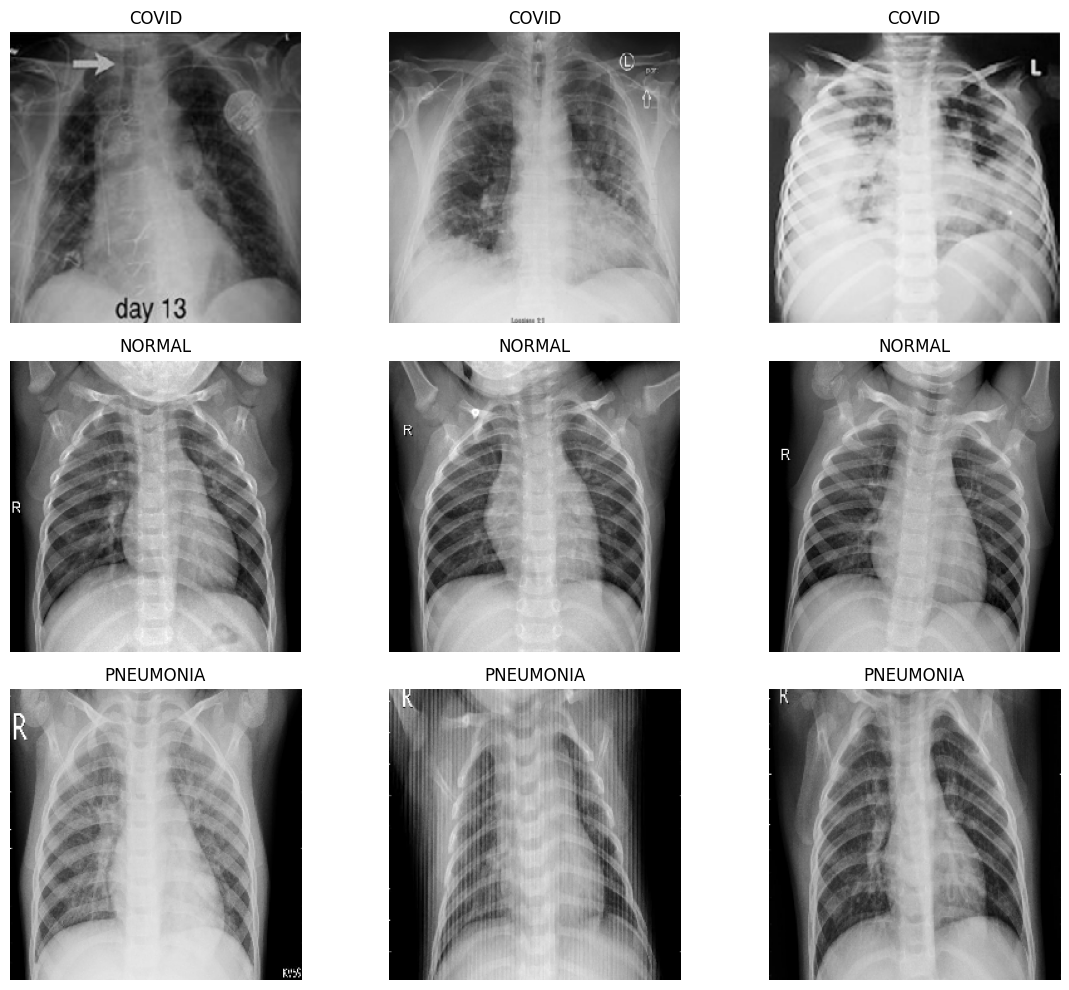

In [11]:
classes = ["COVID", "NORMAL", "PNEUMONIA"]

plt.figure(figsize=(12,10))

plot_index = 1

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    images = [img for img in os.listdir(class_path) if img.endswith(('.png', '.jpg', '.jpeg'))]

    sample_images = random.sample(images, 3)

    for img_name in sample_images:
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path).convert("RGB")

        plt.subplot(3, 3, plot_index)
        plt.imshow(img)
        plt.title(cls)
        plt.axis('off')

        plot_index += 1

plt.tight_layout()
plt.show()

## Bar Chart

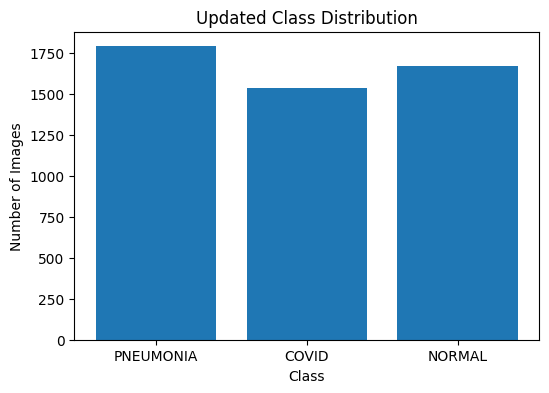

In [12]:
plt.figure(figsize=(6,4))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Updated Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

## Pie Chart

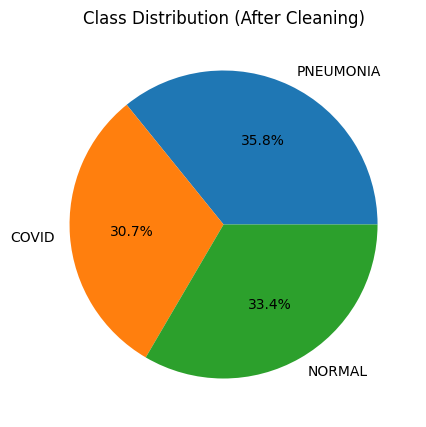

In [13]:
plt.figure(figsize=(5,5))
plt.pie(class_counts.values(), labels=class_counts.keys(), autopct='%1.1f%%')
plt.title("Class Distribution (After Cleaning)")
plt.show()

## Image Size Check

In [14]:
for cls in ["COVID", "NORMAL", "PNEUMONIA"]:
    class_path = os.path.join(dataset_path, cls)
    img_name = os.listdir(class_path)[0]
    img = Image.open(os.path.join(class_path, img_name))
    print(f"{cls} image size:", img.size)

COVID image size: (232, 232)
NORMAL image size: (256, 256)
PNEUMONIA image size: (256, 256)


## Pixel Intensity Histogram

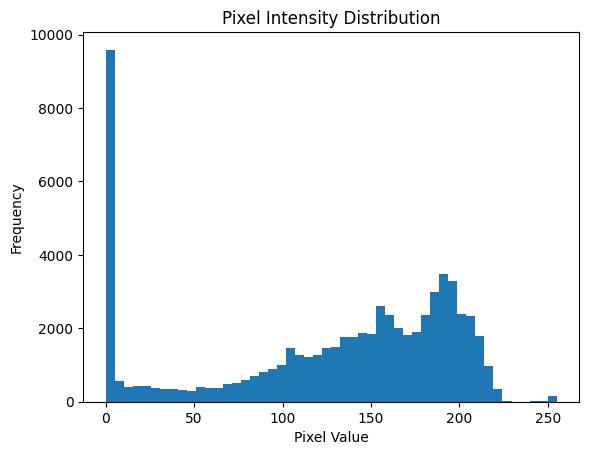

In [15]:
img_array = np.array(img.convert("L"))

plt.hist(img_array.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

## Image Preprocessing and Data Generators

In [16]:
base_dir = "/content/drive/MyDrive/Covid19-Pneumonia-Normal Chest X-Ray Images Dataset"
split_base_path = "/content/covid_split"

train_path = os.path.join(split_base_path, "train")
val_path = os.path.join(split_base_path, "val")
test_path = os.path.join(split_base_path, "test")

classes = ["COVID", "NORMAL", "PNEUMONIA"]

img_size = (224, 224)
batch_size = 32


if os.path.exists(train_path) and len(os.listdir(train_path)) > 0:
    print("Dataset split already exists. Skipping splitting step.")
else:
    print("⚡ Creating dataset split...")

    for split in ["train", "val", "test"]:
        for cls in classes:
            os.makedirs(os.path.join(split_base_path, split, cls), exist_ok=True)

    train_ratio = 0.7
    val_ratio = 0.15

    for cls in classes:
        class_path = os.path.join(base_dir, cls)
        images = [img for img in os.listdir(class_path) if img.endswith(('.png', '.jpg', '.jpeg'))]

        random.shuffle(images)

        total = len(images)
        train_end = int(train_ratio * total)
        val_end = int((train_ratio + val_ratio) * total)

        train_imgs = images[:train_end]
        val_imgs = images[train_end:val_end]
        test_imgs = images[val_end:]

        for img in train_imgs:
            shutil.copy(os.path.join(class_path, img),
                        os.path.join(train_path, cls, img))

        for img in val_imgs:
            shutil.copy(os.path.join(class_path, img),
                        os.path.join(val_path, cls, img))

        for img in test_imgs:
            shutil.copy(os.path.join(class_path, img),
                        os.path.join(test_path, cls, img))

    print("Dataset split completed successfully.")

⚡ Creating dataset split...
Dataset split completed successfully.


## Data Generators

In [17]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    val_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

print("\nClass indices:")
print(train_generator.class_indices)

x_batch, y_batch = next(train_generator)
print("\nImage batch shape:", x_batch.shape)
print("Label batch shape:", y_batch.shape)

Found 3497 images belonging to 3 classes.
Found 751 images belonging to 3 classes.
Found 751 images belonging to 3 classes.

Class indices:
{'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 3)


## Baseline CNN Model

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

baseline_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

baseline_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

history_baseline = baseline_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 60s 471ms/step - accuracy: 0.7332 - loss: 0.6631 - val_accuracy: 0.8549 - val_loss: 0.3808 - learning_rate: 0.0010
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 46s 417ms/step - accuracy: 0.8530 - loss: 0.3968 - val_accuracy: 0.9214 - val_loss: 0.2540 - learning_rate: 0.0010
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 45s 410ms/step - accuracy: 0.8910 - loss: 0.3153 - val_accuracy: 0.9241 - val_loss: 0.2097 - learning_rate: 0.0010
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 46s 421ms/step - accuracy: 0.9036 - loss: 0.2643 - val_accuracy: 0.9294 - val_loss: 0.2155 - learning_rate: 0.0010
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 46s 412ms/step - accuracy: 0.9159 - loss: 0.2508 - val_accuracy: 0.9454 - val_loss: 0.1672 - learning_rate: 0.0010
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 46s 416ms/step - accuracy: 0.9142 - loss: 0.2444 - val_accuracy: 0.9534 - val_loss: 0.1556 - learning_rate: 0.0010
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 45s 412ms/step - accuracy: 0.9